<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/04_natural_language_processing/06_glove_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GloVe (Global Vectors for Word Representation)

GloVe is a word embedding technique developed by researchers at Stanford University. Unlike Word2Vec, which learns embeddings by predicting context words, GloVe learns word representations by analyzing how frequently words co-occur across the entire corpus.

The intuition behind GloVe is that words appearing together frequently are likely to have related meanings. It constructs a word co-occurrence matrix and learns dense vector representations that preserve these global relationships.

Like Word2Vec, GloVe produces dense embeddings where semantically similar words are located close together in vector space. Many pre-trained GloVe models are publicly available and are widely used in NLP applications.

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.0 MB/s eta 0:00:00


In [4]:
import gensim.downloader as api
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
glove_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


In [6]:
print(len(glove_model.index_to_key))

400000


In [7]:
vector = glove_model["computer"]

print(vector)

[ 0.079084 -0.81504   1.7901    0.91653   0.10797  -0.55628  -0.84427
 -1.4951    0.13418   0.63627   0.35146   0.25813  -0.55029   0.51056
  0.37409   0.12092  -1.6166    0.83653   0.14202  -0.52348   0.73453
  0.12207  -0.49079   0.32533   0.45306  -1.585    -0.63848  -1.0053
  0.10454  -0.42984   3.181    -0.62187   0.16819  -1.0139    0.064058
  0.57844  -0.4556    0.73783   0.37203  -0.57722   0.66441   0.055129
  0.037891  1.3275    0.30991   0.50697   1.2357    0.1274   -0.11434
  0.20709 ]


In [8]:
print(vector.shape)

(50,)


In [9]:
similar_words = glove_model.most_similar("computer")

similar_df = pd.DataFrame(

    similar_words,

    columns=["Word", "Similarity"]

)

similar_df

,Word,Similarity
0,computers,0.916505
1,software,0.881499
2,technology,0.852556
3,electronic,0.812587
4,internet,0.806046
5,computing,0.802604
6,devices,0.801619
7,digital,0.799179
8,applications,0.791274
9,pc,0.788316


In [10]:
similarity = glove_model.similarity(

    "computer",

    "laptop"

)

print(similarity)

0.77411586


In [11]:
result = glove_model.most_similar(

    positive=["king", "woman"],

    negative=["man"],

    topn=5

)

analogy_df = pd.DataFrame(

    result,

    columns=["Word", "Score"]

)

analogy_df

,Word,Score
0,queen,0.852360
1,throne,0.766433
2,prince,0.759214
3,daughter,0.747388
4,elizabeth,0.746022


In [12]:
comparison = pd.DataFrame({

    "Word2Vec":[

        "Predictive model",

        "Uses local context",

        "Learns during prediction"

    ],

    "GloVe":[

        "Count-based model",

        "Uses global co-occurrence",

        "Learns from statistics"

    ]

})

comparison

,Word2Vec,GloVe
0,Predictive model,Count-based model
1,Uses local context,Uses global co-occurrence
2,Learns during prediction,Learns from statistics


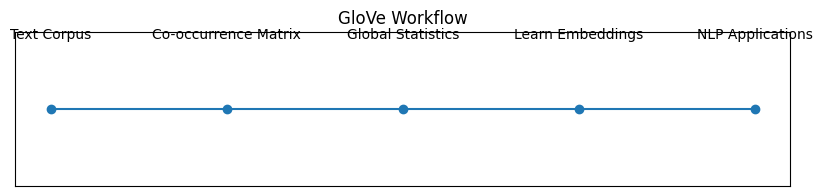

In [13]:
steps = [

    "Text Corpus",

    "Co-occurrence Matrix",

    "Global Statistics",

    "Learn Embeddings",

    "NLP Applications"

]

plt.figure(figsize=(10,2))

plt.plot(range(len(steps)),
         [1]*len(steps),
         marker="o")

for i, step in enumerate(steps):

    plt.text(i,1.05,step,ha="center")

plt.xticks([])
plt.yticks([])

plt.title("GloVe Workflow")

plt.show()